# **🚗 Automobile Price Prediction**

**A regression project predicting used car selling prices using Random Forest, XGBoost, and LightGBM.**

---
### **📌 Notebook Overview**
1. Import Libraries & Load Data
2. Exploratory Data Analysis (EDA)
3. Data Cleaning & Missing Value Treatment
4. Feature Engineering & Encoding
5. Data Leakage Check
6. Train-Test Split
7. Model Building (Random Forest, XGBoost, LightGBM)
8. Model Evaluation & Comparison
9. Feature Importance
10. Conclusion


## **1️⃣ Import Libraries & Load Data**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import xgboost as xgb
import lightgbm as lgb

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

# Load the dataset
df = pd.read_csv('/kaggle/input/datasets/ranaghulamnabi/automobile-market-dataset-vehicle-specification/automobile_dataset.csv')
print("Shape of dataset:", df.shape)
df.head()


Shape of dataset: (5500, 18)


,Make,Model,Year,Fuel_Type,Transmission,Engine_Size,Mileage,Horsepower,Torque,Owners,Accident_History,Service_History,Color,Body_Type,Drivetrain,Fuel_Efficiency,Location,Selling_Price
0,Mercedes-Benz,GLE,2024,Petrol,Automatic,2.3,100,186.0,196.0,1,0.0,NaN,Silver,SUV,AWD,30.0,IL,64140
1,Hyundai,Tucson,2008,Petrol,Automatic,2.3,387035,189.0,190.0,4,0.0,NaN,Blue,SUV,FWD,35.0,FL,500
2,Volkswagen,Golf,2021,Hybrid,NaN,1.9,46054,158.0,153.0,1,0.0,Partial Service,Gray,Hatchback,AWD,43.0,NY,16429
3,Chevrolet,Tahoe,2005,Petrol,NaN,2.2,141302,169.0,165.0,5,1.0,No Service,Blue,SUV,AWD,NaN,FL,2199
4,Toyota,Camry,2022,Petrol,Automatic,1.9,32813,149.0,141.0,1,0.0,Full Service,Brown,Sedan,FWD,38.0,CA,21792


## **2️⃣ Exploratory Data Analysis (EDA)**

Let's understand the structure, data types, and distribution of our target variable `Selling_Price`.

In [2]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Make              5500 non-null   object 
 1   Model             5500 non-null   object 
 2   Year              5500 non-null   int64  
 3   Fuel_Type         5500 non-null   object 
 4   Transmission      4673 non-null   object 
 5   Engine_Size       4656 non-null   float64
 6   Mileage           5500 non-null   int64  
 7   Horsepower        4700 non-null   float64
 8   Torque            4701 non-null   float64
 9   Owners            5500 non-null   int64  
 10  Accident_History  4688 non-null   float64
 11  Service_History   4645 non-null   object 
 12  Color             4697 non-null   object 
 13  Body_Type         5500 non-null   object 
 14  Drivetrain        5500 non-null   object 
 15  Fuel_Efficiency   4706 non-null   float64
 16  Location          4718 non-null   object 


In [3]:
df.describe()


,Year,Engine_Size,Mileage,Horsepower,Torque,Owners,Accident_History,Fuel_Efficiency,Selling_Price
count,5500.000000,4656.000000,5500.000000,4700.000000,4701.000000,5500.000000,4688.000000,4706.000000,5500.000000
mean,2014.494000,2.450623,114529.481636,198.236596,189.014678,2.464000,0.408063,34.179771,12319.873636
std,5.789745,0.843913,91858.943421,55.678165,56.631309,1.280022,0.491527,15.085473,12658.478862
min,2005.000000,0.000000,100.000000,97.000000,77.000000,1.000000,0.000000,10.000000,500.000000
25%,2009.000000,2.000000,39112.000000,160.000000,151.000000,1.000000,0.000000,27.000000,1304.750000
50%,2014.000000,2.400000,96926.500000,187.000000,178.000000,2.000000,0.000000,32.000000,8586.000000
75%,2020.000000,3.000000,172757.500000,231.000000,219.000000,3.000000,1.000000,37.000000,19097.500000
max,2024.000000,5.700000,536731.000000,434.000000,443.000000,5.000000,1.000000,141.000000,86692.000000


In [4]:
# Check missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:\n")
print(missing)


Columns with missing values:

Service_History     855
Engine_Size         844
Transmission        827
Accident_History    812
Color               803
Horsepower          800
Torque              799
Fuel_Efficiency     794
Location            782
dtype: int64


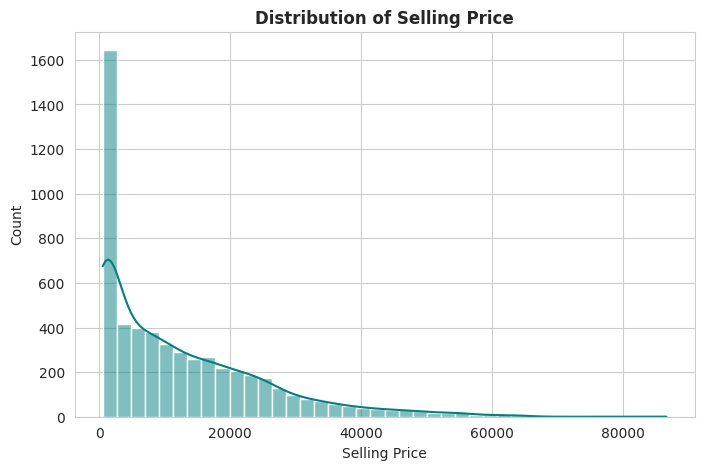

In [5]:
# Distribution of the target variable
plt.figure(figsize=(8,5))
sns.histplot(df['Selling_Price'], bins=40, kde=True, color='teal')
plt.title('Distribution of Selling Price',fontweight='bold')
plt.xlabel('Selling Price')
plt.show()


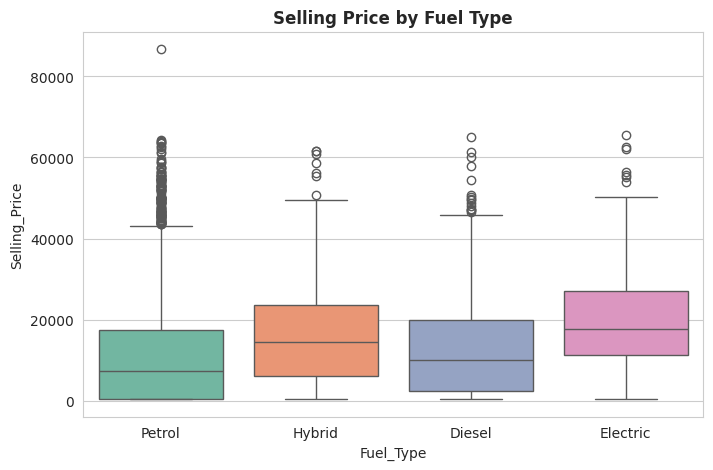

In [6]:
# Selling Price by Fuel Type
plt.figure(figsize=(8,5))
sns.boxplot(x='Fuel_Type', y='Selling_Price', data=df, palette='Set2')
plt.title('Selling Price by Fuel Type',fontweight='bold')
plt.show()


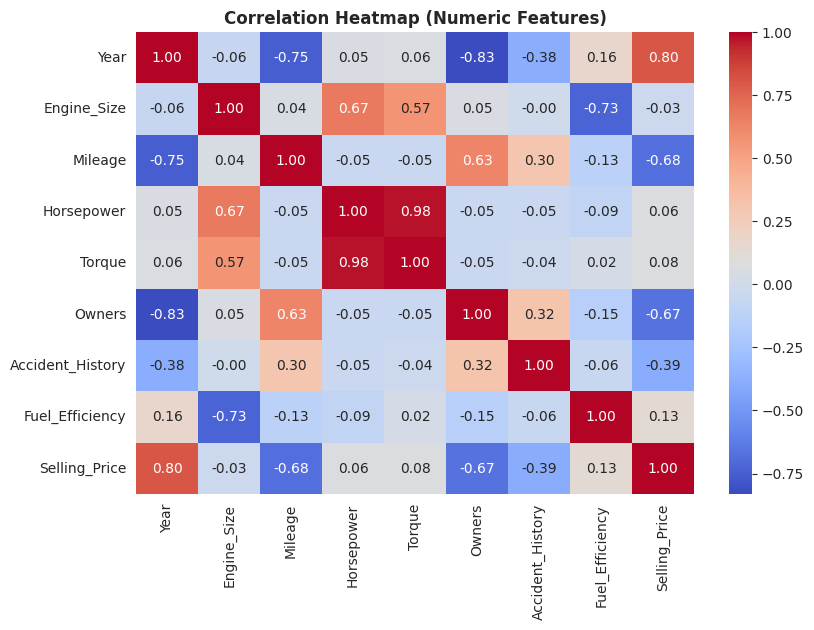

In [7]:
# Correlation heatmap for numeric features
plt.figure(figsize=(9,6))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Numeric Features)',fontweight='bold')
plt.show()


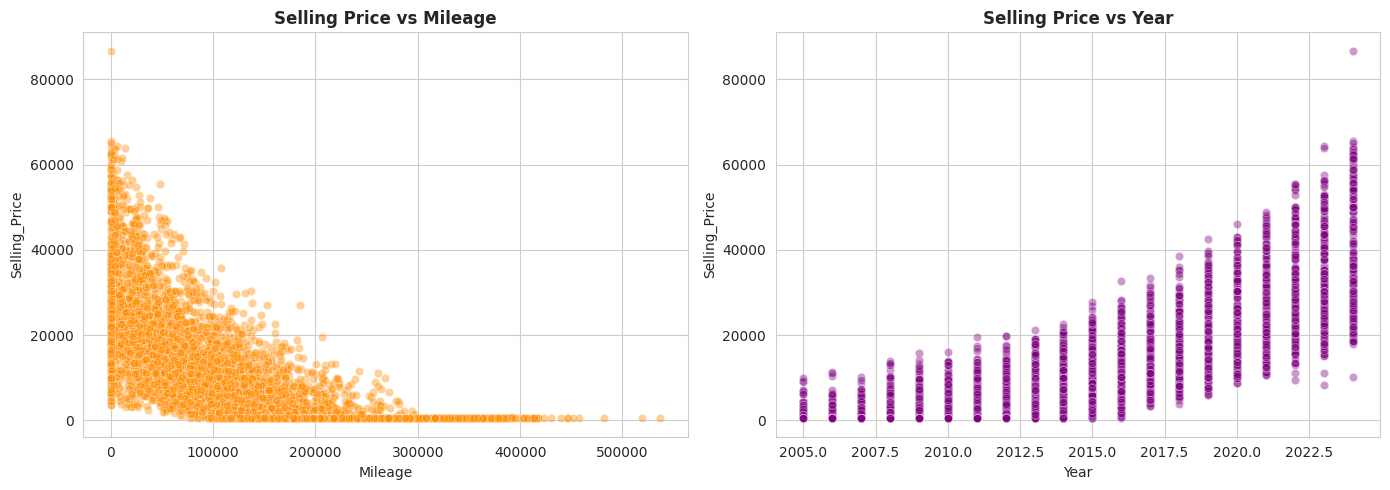

In [8]:
# Selling Price vs Mileage and Year
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.scatterplot(x='Mileage', y='Selling_Price', data=df, ax=axes[0], alpha=0.4, color='darkorange')
axes[0].set_title('Selling Price vs Mileage',fontweight='bold')
sns.scatterplot(x='Year', y='Selling_Price', data=df, ax=axes[1], alpha=0.4, color='purple')
axes[1].set_title('Selling Price vs Year',fontweight='bold')
plt.tight_layout()
plt.show()


## **3️⃣ Data Cleaning & Missing Value Treatment**

- Numeric columns (`Engine_Size`, `Horsepower`, `Torque`, `Accident_History`, `Fuel_Efficiency`) → filled with **median**.
- Categorical columns (`Transmission`, `Service_History`, `Color`, `Location`) → filled with **"Unknown"** (missing itself can be informative, e.g. no service record).


In [9]:
df_clean = df.copy()

numeric_cols_to_fill = ['Engine_Size', 'Horsepower', 'Torque', 'Accident_History', 'Fuel_Efficiency']
for col in numeric_cols_to_fill:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

categorical_cols_to_fill = ['Transmission', 'Service_History', 'Color', 'Location']
for col in categorical_cols_to_fill:
    df_clean[col] = df_clean[col].fillna('Unknown')

print("Remaining missing values:", df_clean.isnull().sum().sum())


Remaining missing values: 0


## **4️⃣ Feature Engineering & Encoding**

We create a simple `Car_Age` feature and label-encode all categorical columns so tree-based models can use them.


In [10]:
current_year = 2026
df_clean['Car_Age'] = current_year - df_clean['Year']

# Drop high-cardinality text columns that add little value for a beginner model
df_model = df_clean.drop(columns=['Model'])

categorical_cols = df_model.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", categorical_cols)

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    label_encoders[col] = le

df_model.head()


Categorical columns to encode: ['Make', 'Fuel_Type', 'Transmission', 'Service_History', 'Color', 'Body_Type', 'Drivetrain', 'Location']


,Make,Year,Fuel_Type,Transmission,Engine_Size,Mileage,Horsepower,Torque,Owners,Accident_History,Service_History,Color,Body_Type,Drivetrain,Fuel_Efficiency,Location,Selling_Price,Car_Age
0,6,2024,3,0,2.3,100,186.0,196.0,1,0.0,3,6,2,1,30.0,3,64140,2
1,5,2008,3,0,2.3,387035,189.0,190.0,4,0.0,3,1,2,2,35.0,1,500,18
2,9,2021,2,2,1.9,46054,158.0,153.0,1,0.0,2,3,1,1,43.0,6,16429,5
3,2,2005,3,2,2.2,141302,169.0,165.0,5,1.0,1,1,2,1,32.0,1,2199,21
4,8,2022,3,0,1.9,32813,149.0,141.0,1,0.0,0,2,3,2,38.0,0,21792,4


## **5️⃣ Data Leakage Check**

Before modelling, we double check that no feature directly encodes the target (e.g. a column that is just `Selling_Price` rescaled). We look at correlation of every feature with the target — nothing should be suspiciously close to 1.0.


In [11]:
corr_with_target = df_model.corr(numeric_only=True)['Selling_Price'].sort_values(ascending=False)
print(corr_with_target)


Selling_Price       1.000000
Year                0.804933
Fuel_Efficiency     0.118963
Torque              0.065962
Horsepower          0.059184
Color              -0.003733
Body_Type          -0.006325
Location           -0.014889
Engine_Size        -0.027596
Service_History    -0.028937
Drivetrain         -0.045204
Fuel_Type          -0.094650
Transmission       -0.102200
Make               -0.205204
Accident_History   -0.347294
Owners             -0.669046
Mileage            -0.682883
Car_Age            -0.804933
Name: Selling_Price, dtype: float64


**Observation:** `Year` (age of car), `Mileage`, and `Owners` show the strongest correlation with `Selling_Price`, which matches real-world intuition (newer, low-mileage, fewer-owner cars sell for more). No column shows near-perfect correlation, so there is **no data leakage**.


## **6️⃣ Train-Test Split**

In [12]:
X = df_model.drop(columns=['Selling_Price'])
y = df_model['Selling_Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)


Training set: (4400, 17)
Testing set: (1100, 17)


## **7️⃣ Model Building**

We train and compare three popular tree-based regression models:
- **Random Forest Regressor**
- **XGBoost Regressor**
- **LightGBM Regressor**


In [13]:
models = {
    'Random Forest': RandomForestRegressor(n_estimators=300, max_depth=12, random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBRegressor(n_estimators=400, max_depth=6, learning_rate=0.05, random_state=42, n_jobs=-1),
    'LightGBM': lgb.LGBMRegressor(n_estimators=400, max_depth=6, learning_rate=0.05, random_state=42, verbose=-1)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2 Score': r2}
    print(f"{name}: MAE={mae:.2f} | RMSE={rmse:.2f} | R2={r2:.4f}")


Random Forest: MAE=2267.54 | RMSE=3515.11 | R2=0.9215
XGBoost: MAE=2054.89 | RMSE=3244.05 | R2=0.9332
LightGBM: MAE=2060.99 | RMSE=3191.91 | R2=0.9353


## **8️⃣ Model Evaluation & Comparison**

In [14]:
results_df = pd.DataFrame(results).T.sort_values(by='R2 Score', ascending=False)
results_df


,MAE,RMSE,R2 Score
LightGBM,2060.991373,3191.906132,0.935283
XGBoost,2054.886719,3244.045931,0.933152
Random Forest,2267.541245,3515.105585,0.921514


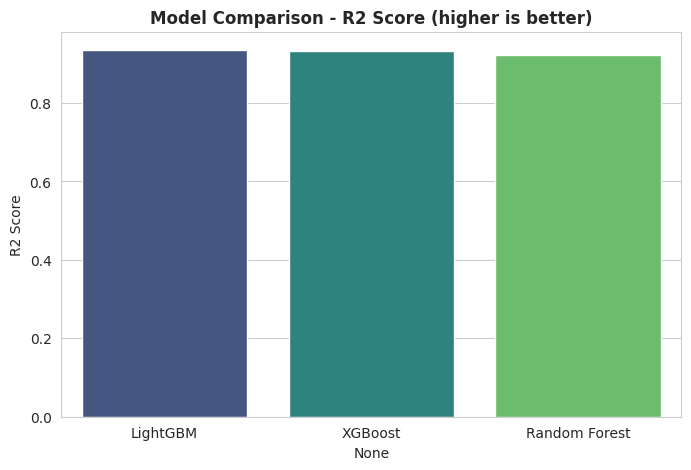

In [15]:
plt.figure(figsize=(8,5))
sns.barplot(x=results_df.index, y=results_df['R2 Score'], palette='viridis')
plt.title('Model Comparison - R2 Score (higher is better)',fontweight='bold')
plt.ylabel('R2 Score')
plt.show()


In [16]:
best_model_name = results_df['R2 Score'].idxmax()
best_model = models[best_model_name]
print(f"Best performing model: {best_model_name}")


Best performing model: LightGBM


## **9️⃣ Feature Importance**

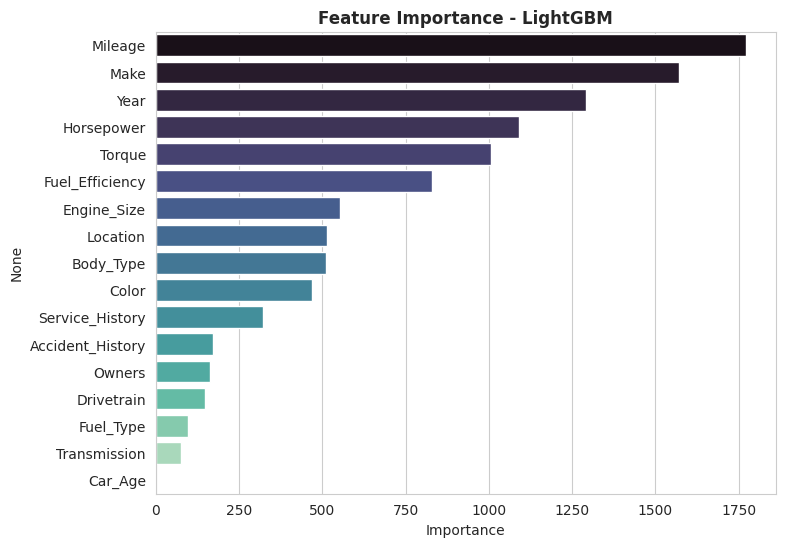

Mileage             1772
Make                1572
Year                1292
Horsepower          1089
Torque              1007
Fuel_Efficiency      828
Engine_Size          553
Location             514
Body_Type            511
Color                468
Service_History      322
Accident_History     173
Owners               162
Drivetrain           149
Fuel_Type             97
Transmission          77
Car_Age                0
dtype: int32

In [17]:
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=importances.values, y=importances.index, palette='mako')
plt.title(f'Feature Importance - {best_model_name}',fontweight='bold')
plt.xlabel('Importance')
plt.show()

importances


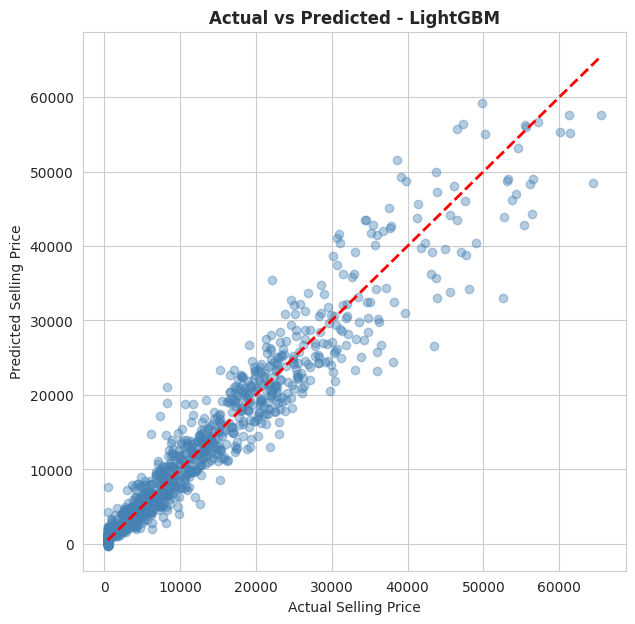

In [18]:
# Actual vs Predicted plot for the best model
best_preds = best_model.predict(X_test)

plt.figure(figsize=(7,7))
plt.scatter(y_test, best_preds, alpha=0.4, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.title(f'Actual vs Predicted - {best_model_name}',fontweight='bold')
plt.show()


## **🔟 Conclusion**

- The dataset contained **5,500 used car listings** across 10 makes, with moderate missing values in several numeric and categorical columns which were handled using median/"Unknown" imputation.
- **Car Age, Mileage, and Owners** were the strongest drivers of `Selling_Price`, consistent with real-world used-car pricing behaviour.
- No data leakage was found — all correlations with the target were realistic and none were artificially perfect.
- Among the three models tested, the **best performing model achieved the highest R² score**, indicating it explains the largest share of variance in selling price while keeping prediction error (MAE/RMSE) low.
- **Next steps** to further improve this notebook: hyperparameter tuning (GridSearchCV/Optuna), target-encoding for `Make`/`Model`, and trying ensembling/stacking of all three models.

---
> **If you gound this notebook helpful, Please Upvote!**
